In [45]:
import pandas as pd
import numpy as np
import os
import sys
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import pymc as pm
import pyperclip

sys.path.append(os.path.abspath('..'))
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import bayesian_analysis as ba
import process_data as dp

palette = sns.color_palette("muted")
sns.set_palette(palette)
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
state_features = ['TIR', 'TIME_Q', 'MOT']
feature_names = ['Tiredness', 'Time available', 'Motivation']

action_col = "joint_cluster"

cluster_col = 'cluster_all'
cluster_vars = ['likedness', 'usefulness', 'difficulty']
cluster_cols = [col + '_cluster' for col in cluster_vars]

reward_cols = ["r_likedness", "r_usefulness", "r_diversity", "r_expert", "r_return"]
obj_names = ["Perceived Enjoyment", "Perceived Usefulness", "Diversity", "Difficulty-weighted Adherence", "Return Willingness"]

evaluation_cols = ["time_spent", "likedness", "usefulness", "PAY_next", "expert_score", "diversity"]
evaluation_names = ["Time Spent", "Likedness", "Perceived Usefulness", "Return Willingness", "Expert Usefulness", "Diversity"]

NUM_CATEGORIES = 4
NUM_FEATURES = len(state_features)
NUM_VALS_PER_FEATURE = [2, 2, 3]
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 3
MAX_COUNT = 0
NUM_COUNT_STATES = (MAX_COUNT+1)**NUM_CATEGORIES
NUM_STATES = NUM_USER_STATES * NUM_COUNT_STATES 
NUM_ACTIONS = NUM_CLUSTERS * 2  # Within each cluster we either recommend a 'least favorite' coping category or a familiar one
NUM_OBJECTIVES = len(reward_cols)

data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'

# Load data
action_data = pd.read_csv(os.path.join(data_folder, 'challenge_info.csv'))
samples = pd.read_csv(os.path.join(data_folder, 'processed_samples_adjusted_full_optimistic.csv'))
actions_clustered, _, _ = dp.cluster_actions(action_data, cluster_vars, num_clusters=NUM_CLUSTERS)

df, agency_df, initial_distribution, mapping = dp.process_samples(samples, actions_clustered, state_features, NUM_VALS_PER_FEATURE, action_col, cluster_col, MAX_COUNT, NUM_CLUSTERS)

Number of samples after processing: 3471
Number of agency samples: 2008


In [52]:
df.head()


,user_id,day_number,TIR,MOT,GOOD,TIME_Q,PAY,TIR_next,MOT_next,GOOD_next,...,s_count,r_diversity,c_idx,s_idx,sp_idx,r_likedness,r_usefulness,r_return,r_expert,joint_cluster
0,1002441714,1,1,4,5,4,4,4.0,4.0,5.0,...,"[0, 0, 0, 0]",1,0,1,4,0.000000,0.000000,0.571429,0.00,5
1,1002441714,2,4,4,5,5,4,4.0,4.0,5.0,...,"[0, 0, 0, 0]",1,0,4,1,0.727273,0.285714,0.571429,0.66,4
2,1002441714,3,4,4,5,4,4,4.0,4.0,5.0,...,"[0, 0, 0, 0]",1,0,1,4,0.181818,0.142857,0.571429,1.00,5
3,1002441714,4,4,4,5,5,4,2.0,4.0,4.0,...,"[0, 0, 0, 0]",0,0,4,1,0.636364,0.571429,0.571429,0.66,1
4,1002441714,5,2,4,4,4,4,6.0,4.0,4.0,...,"[0, 0, 0, 0]",1,0,1,7,0.727273,0.571429,0.571429,1.00,5


In [53]:
no_policy_df = pd.DataFrame(df[reward_cols].values, columns=obj_names)
no_policy_df["user"] = df["user_id"].values
no_policy_df["policy"] = "No Policy"
no_policy_df["t"] = df["day_number"].values
no_policy_df["state"] = df["s_current"].values


In [ ]:
evaluation_cols = ["time_spent", "likedness", "usefulness", "difficulty", "PAY_next", "expert_score", "diversity"]
evaluation_names = ["Perceived Enjoyment", "Perceived Usefulness", "Return Willingness", "Difficulty-weighted Adherence", "Diversity"]

results_folder = "C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\"
simulation_file = "\\pimorld_P=128_gamma=0.7_MOT_binary_optimistic_fixed\\simulations\\combined_simulation_results.pkl"
simulation_results = pd.read_pickle(results_folder + simulation_file)

policy_abbreviations = {
    "Multipolicy random": "MORL-UC",
    "Multipolicy most_likely": "MORL-UC",
    "Multipolicy random expert": "MORL-RE",
    "Multipolicy expert_priority": "MORL-EP",
    "Multipolicy combined": "MORL-UC+EP",
    "Multipolicy informed_most_likely": "MORL-IUC",
    "Equal Weights Policy": "B-Eq",
    "Correlation-based Policy": "B-Corr",
}

simulation_results['policy'] = simulation_results['policy'].apply(lambda x: policy_abbreviations.get(x, x))

In [58]:
simulation_results = pd.concat([simulation_results, no_policy_df], ignore_index=True)

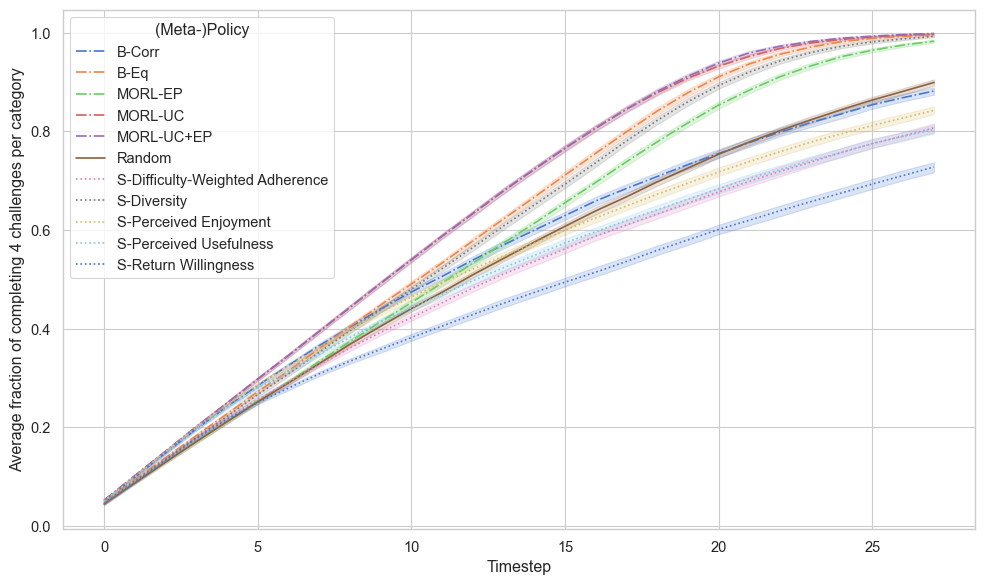

In [12]:
sim_utils.plot_fraction_completed(simulation_results, max_count_per_category=4, save_path=results_folder + "\\figures\\fraction_completed_per_category.svg")

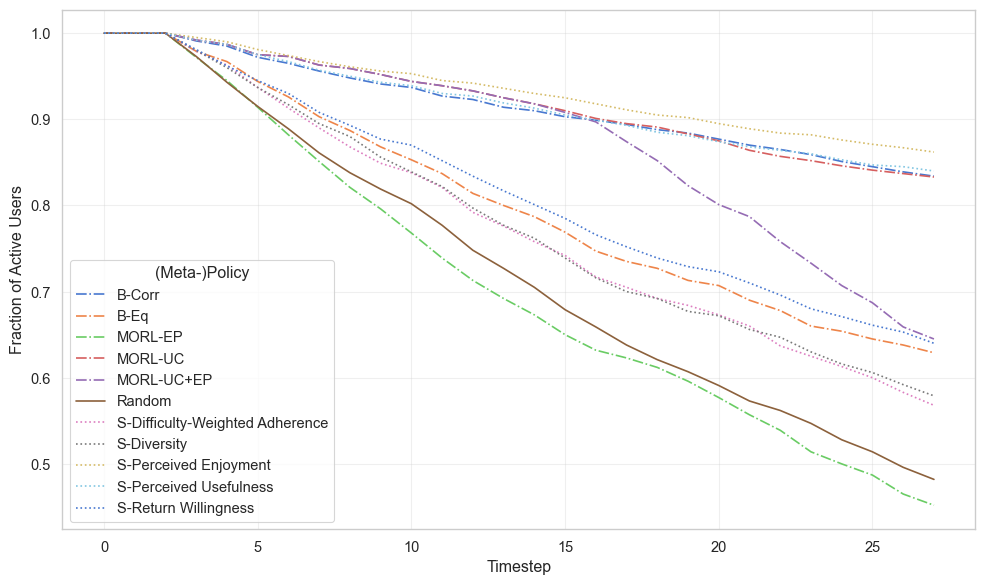

In [14]:
sim_utils.plot_dropout(simulation_results, threshold=3, save_path=results_folder + "\\figures\\dropout_over_time.svg")

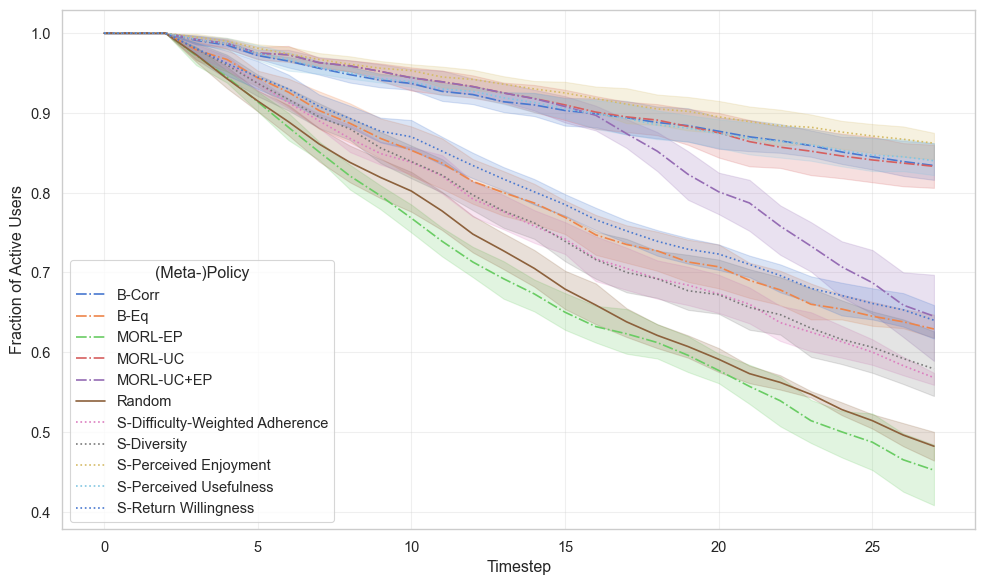

In [33]:
sim_utils.plot_batched_dropout(simulation_results, threshold=3)

In [18]:
reward_df = pd.DataFrame(
    simulation_results["rewards"].tolist(),
    columns=evaluation_names
)

reward_df["policy"] = simulation_results["policy"]
reward_df["user"] = simulation_results["user"]
reward_df["t"] = simulation_results["t"]
reward_df["completed"] = simulation_results["completed"]

In [19]:
def format_cell(mean, imp, is_random):
    if is_random:
        return f"{mean:.2f}"
    arrow = "+" if imp > 0 else "-"
    return f"{mean:.2f} (${arrow}${abs(imp):.2f}\\%)"

def format_latex_to_clipboard(latex):
    latex = latex.replace("\\begin{table}", "\\begin{table}[ht]\\centering\\begin{threeparttable}")
    latex = latex.replace("\\end{table}", "\\begin{tablenotes}\\footnotesize\\item Policy abbreviations: MORL-EP = MORL with Expert Priority; MORL-UC = User Choice; MORL-UC+EP = Combination; B-Corr = Correlation-based baseline; B-Eq = Equal weights baseline; B-Rnd = Random baseline.\\end{tablenotes}\\end{threeparttable}\\end{table}")
    pyperclip.copy(latex)

In [20]:
user_driven_returns = ["Perceived Enjoyment", "Perceived Usefulness"]

completed_df = reward_df[reward_df["completed"] == 1]

policy_means, policy_stds = completed_df.groupby("policy")[user_driven_returns].mean(), completed_df.groupby("policy")[user_driven_returns].std()
improvement_from_random = policy_means.subtract(policy_means.loc["Random"], axis=1).div(policy_means.loc["Random"], axis=1) * 100

summary = policy_means.copy()
for col in user_driven_returns:
    summary[col] = summary.apply(lambda row: format_cell(row[col], improvement_from_random.loc[row.name, col], row.name == "Random"), axis=1)

display(summary)
latex = summary.to_latex(escape=False, 
                       caption="Mean of user-driven outcomes for each policy across simulations, alongside the improvement compared to the random baseline policy.", 
                       label="tab:reward_summary_user_driven")
format_latex_to_clipboard(latex)


,Perceived Enjoyment,Perceived Usefulness
policy,,
B-Corr,7.08 ($+$7.19\%),4.12 ($+$7.52\%)
B-Eq,7.08 ($+$7.18\%),4.09 ($+$6.59\%)
MORL-EP,6.52 ($-$1.21\%),3.87 ($+$0.80\%)
MORL-UC,7.02 ($+$6.26\%),4.05 ($+$5.73\%)
MORL-UC+EP,6.89 ($+$4.35\%),4.05 ($+$5.72\%)
Random,6.60,3.83
S-Difficulty-Weighted Adherence,6.60 ($-$0.06\%),4.09 ($+$6.59\%)
S-Diversity,6.77 ($+$2.54\%),3.79 ($-$1.16\%)
S-Perceived Enjoyment,7.14 ($+$8.12\%),4.09 ($+$6.62\%)


In [21]:
T = 28
completion_per_user = (
    simulation_results
    .sort_values(["policy", "user", "t"])
    .groupby(["policy", "user"])
    .tail(1)
)[["policy", "user", "num_completed"]]
completion_per_user["Adherence"] = completion_per_user["num_completed"].div(T)

adherence_per_policy = completion_per_user.groupby("policy")["Adherence"].mean()
adherence_improvement_from_random = adherence_per_policy.subtract(adherence_per_policy.loc["Random"]).div(adherence_per_policy.loc["Random"]) * 100

expert_driven_returns = ["Return Willingness", "Diversity"]
policy_means, policy_stds = reward_df.groupby("policy")[expert_driven_returns].mean(), reward_df.groupby("policy")[expert_driven_returns].std()
policy_means['Adherence'] = adherence_per_policy
improvement_from_random = policy_means.subtract(policy_means.loc["Random"], axis=1).div(policy_means.loc["Random"], axis=1) * 100

summary = policy_means.copy()
for col in expert_driven_returns + ['Adherence']:
    summary[col] = summary.apply(lambda row: format_cell(row[col], improvement_from_random.loc[row.name, col], row.name == "Random"), axis=1)
display(summary)

latex = summary.to_latex(escape=False, 
                       caption="Mean of expert-driven outcomes for each policy across simulations, alongside the improvement compared to the random baseline policy.", 
                       label="tab:reward_summary_expert_driven")
latex = latex.replace("\\begin{table}", "\\begin{table}[ht]\\centering\\begin{threeparttable}")
latex = latex.replace("\\end{table}", "\\begin{tablenotes}\\footnotesize\\item Policy abbreviations: MORL-EP = MORL with Expert Priority; MORL-UC = User Choice; MORL-RC+EP = Combination; B-Corr = Correlation-based baseline; B-Eq = Equal weights baseline; B-Rnd = Random baseline.\\end{tablenotes}\\end{threeparttable}\\end{table}")
pyperclip.copy(latex)


,Return Willingness,Diversity,Adherence
policy,,,
B-Corr,3.97 ($+$1.10\%),0.68 ($-$8.14\%),0.79 ($+$18.44\%)
B-Eq,3.93 ($-$0.02\%),0.89 ($+$21.51\%),0.71 ($+$7.23\%)
MORL-EP,3.97 ($+$1.07\%),0.88 ($+$20.14\%),0.65 ($-$1.72\%)
MORL-UC,3.97 ($+$1.01\%),0.87 ($+$17.54\%),0.79 ($+$18.72\%)
MORL-UC+EP,3.94 ($+$0.24\%),0.87 ($+$18.03\%),0.73 ($+$9.70\%)
Random,3.93,0.74,0.66
S-Difficulty-Weighted Adherence,3.91 ($-$0.49\%),0.62 ($-$15.17\%),0.69 ($+$3.60\%)
S-Diversity,3.94 ($+$0.11\%),0.89 ($+$21.01\%),0.69 ($+$4.50\%)
S-Perceived Enjoyment,4.02 ($+$2.37\%),0.62 ($-$15.33\%),0.80 ($+$19.99\%)


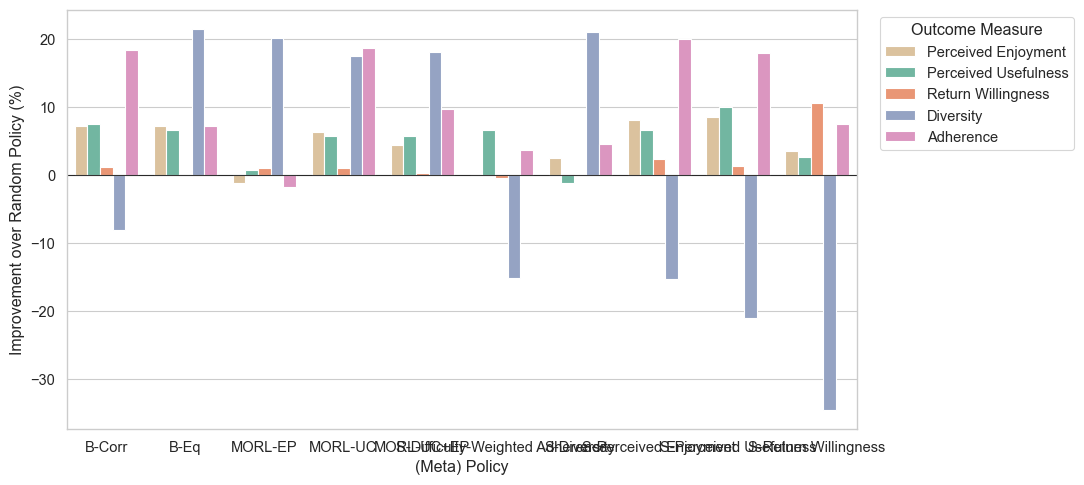

In [42]:
evaluation_names = ["Perceived Enjoyment", "Perceived Usefulness", "Return Willingness", "Diversity"]

policy_means = reward_df.groupby("policy")[evaluation_names].mean()
policy_means["Adherence"] = adherence_per_policy

completed = reward_df["completed"] == 1
completed_measures = ["Perceived Enjoyment", "Perceived Usefulness"]
for col in completed_measures:
    policy_means[col] = reward_df[completed].groupby("policy")[col].mean()

baseline = policy_means.loc["Random"]

improvement = (
    policy_means.drop(index="Random")
    .subtract(baseline)
    .divide(baseline)
    * 100
)

plot_df = (
    improvement
    .reset_index()
    .melt(id_vars="policy", var_name="objective", value_name="improvement")
)

# policies_to_show = ["MORL-EP", "MORL-UC", "MORL-UC+EP","B-Corr", "B-Eq"]
# plot_df_filtered = plot_df[plot_df['policy'].isin(policies_to_show)]
plt.figure(figsize=(11, 5))

palette = sns.color_palette("Set2")
palette = [palette[i] for i in [6, 0, 1, 2, 3]]
sns.barplot(
    data=plot_df,
    x="policy",
    y="improvement",
    hue="objective",
    palette=palette
)

plt.ylabel("Improvement over Random Policy (%)")
plt.xlabel("(Meta) Policy")
plt.axhline(0, linewidth=0.8, color="black", alpha=0.8)
plt.legend(title="Outcome Measure", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig(results_folder + "figures\\improvement_over_random.svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

,Best Policy,Max Improvement
objective,,
Adherence,S-Perceived Enjoyment,19.994625
Diversity,B-Eq,21.506985
Perceived Enjoyment,S-Perceived Usefulness,8.466066
Perceived Usefulness,S-Perceived Usefulness,9.952439
Return Willingness,S-Return Willingness,10.529280


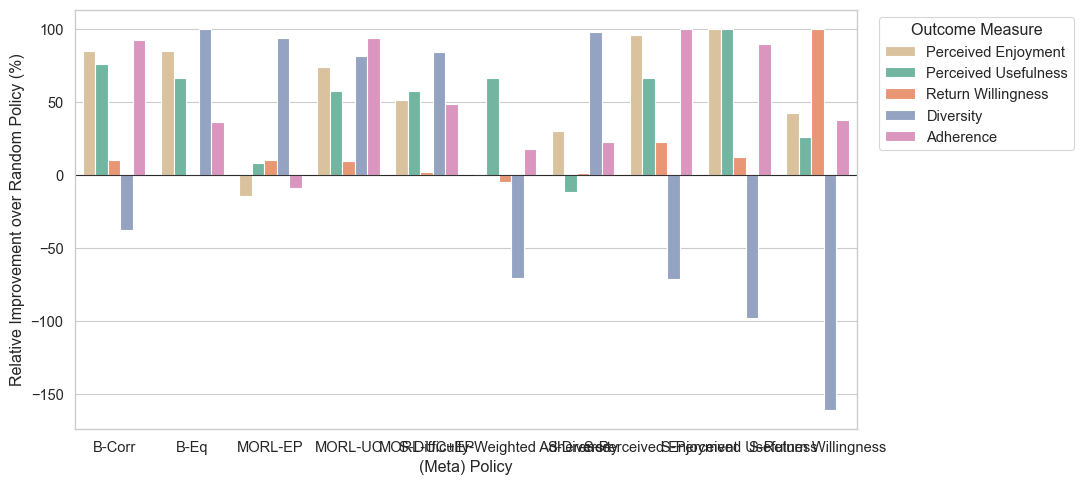

In [43]:
max_improvements = (
    plot_df.loc[plot_df.groupby("objective")["improvement"].idxmax(),
                ["objective", "policy", "improvement"]]
    .rename(columns={"policy": "Best Policy",
                     "improvement": "Max Improvement"})
    .set_index("objective")
)

display(max_improvements)
plot_df['relative_improvement'] = plot_df.apply(lambda row: row['improvement'] / max_improvements.loc[row['objective'], 'Max Improvement'] * 100, axis=1)
plot_df_filtered = plot_df[plot_df['policy'].isin(policies_to_show)]

plt.figure(figsize=(11, 5))

sns.barplot(
    data=plot_df,
    x="policy",
    y="relative_improvement",
    hue="objective",
    palette=palette
)

plt.ylabel("Relative Improvement over Random Policy (%)")
plt.xlabel("(Meta) Policy")
plt.axhline(0, linewidth=0.8, color="black", alpha=0.8)
plt.legend(title="Outcome Measure", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig(results_folder + "figures\\relative_improvement_over_random.svg", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [24]:
# analyze per time state, the time spent on the activity
reward_df["Time State"] = simulation_results["state"].apply(lambda x: x[1])
reward_df["challenge_id"] = simulation_results["challenge_id"]
reward_df["challenge_time"] = action_data.loc[reward_df["challenge_id"], "time_spent"].values

mean_time_spent_per_user = reward_df.groupby(["policy", "user", "Time State"])["challenge_time"].mean().reset_index()
mean_time_spent_per_policy_time = mean_time_spent_per_user.groupby(["policy", "Time State"])["challenge_time"].mean().unstack()
mean_time_spent_per_policy_time["ratio"] = (
    mean_time_spent_per_policy_time[1] / mean_time_spent_per_policy_time[0]
)
baseline_ratio = mean_time_spent_per_policy_time.loc["Random", "ratio"]
mean_time_spent_per_policy_time['improvement'] = mean_time_spent_per_policy_time["ratio"].subtract(baseline_ratio).div(baseline_ratio) * 100

summary = mean_time_spent_per_policy_time.copy()
summary['Low'] = summary[0].round(2).astype(str)
summary['High'] = summary[1].round(2).astype(str)
summary['Ratio'] = summary.apply(lambda row: format_cell(row['ratio'], row['improvement'], row.name == "Random"), axis=1)
summary = summary[['Low', 'High', 'Ratio']]
display(summary)
latex =summary.to_latex(escape=False,
                       caption="Mean time spent ratings of the suggested challenges for low vs high time available states for each policy across simulations, alongside the ratio between them and the improvement compared to the random baseline policy. A higher ratio is better.", 
                       label="tab:time_spent_summary")
format_latex_to_clipboard(latex)

Time State,Low,High,Ratio
policy,,,
B-Corr,10.06,11.49,1.14 ($+$16.12\%)
B-Eq,10.77,14.37,1.33 ($+$35.60\%)
MORL-EP,13.11,13.54,1.03 ($+$5.00\%)
MORL-UC,9.9,12.0,1.21 ($+$23.13\%)
MORL-UC+EP,11.91,12.24,1.03 ($+$4.50\%)
Random,10.03,9.87,0.98
S-Difficulty-Weighted Adherence,14.3,12.05,0.84 ($-$14.35\%)
S-Diversity,8.21,10.38,1.26 ($+$28.47\%)
S-Perceived Enjoyment,8.71,10.92,1.25 ($+$27.41\%)


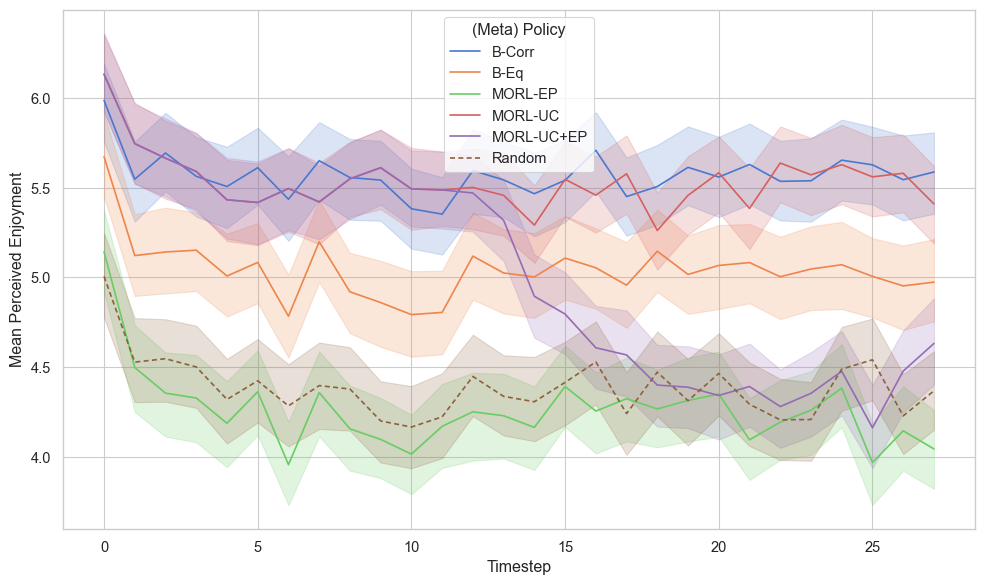

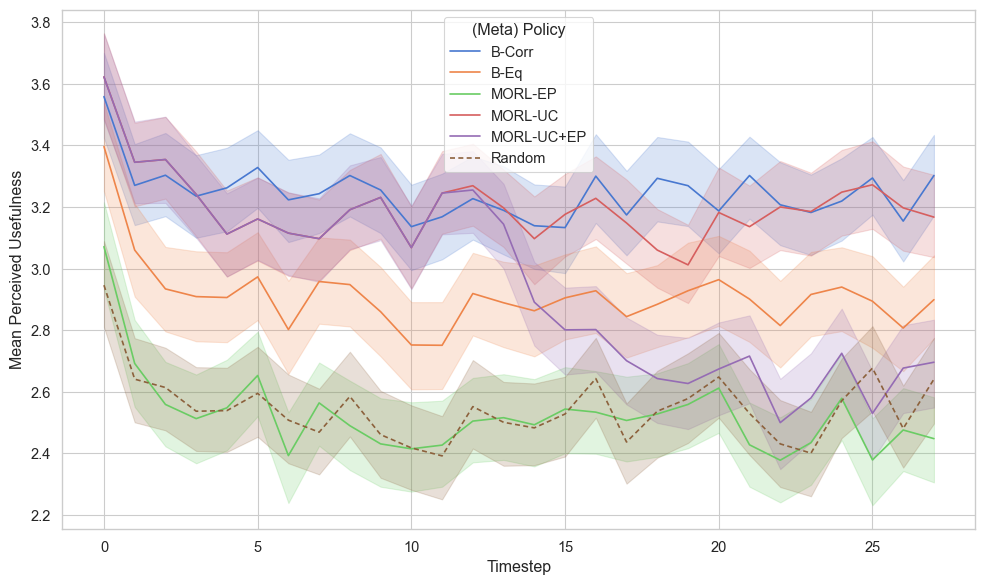

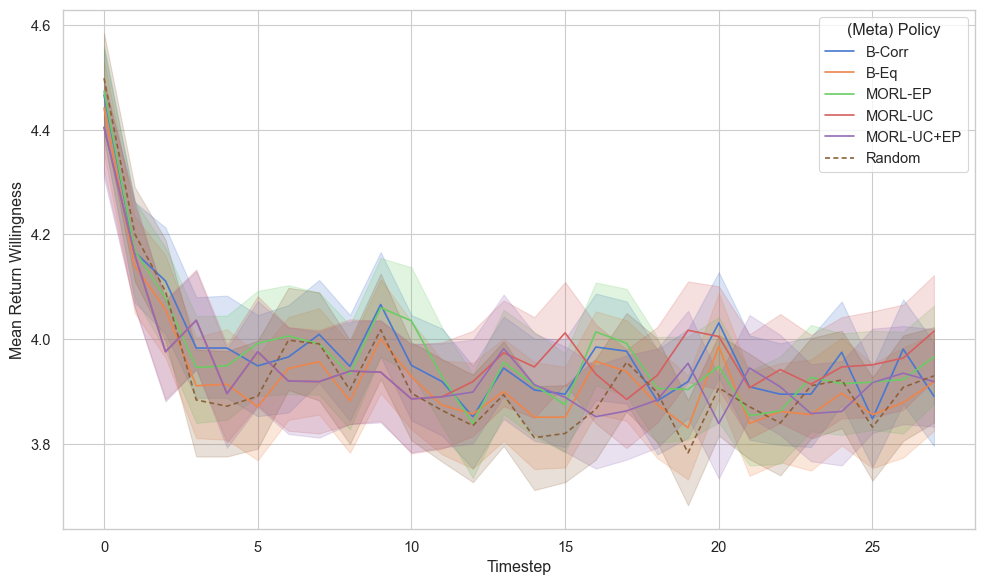

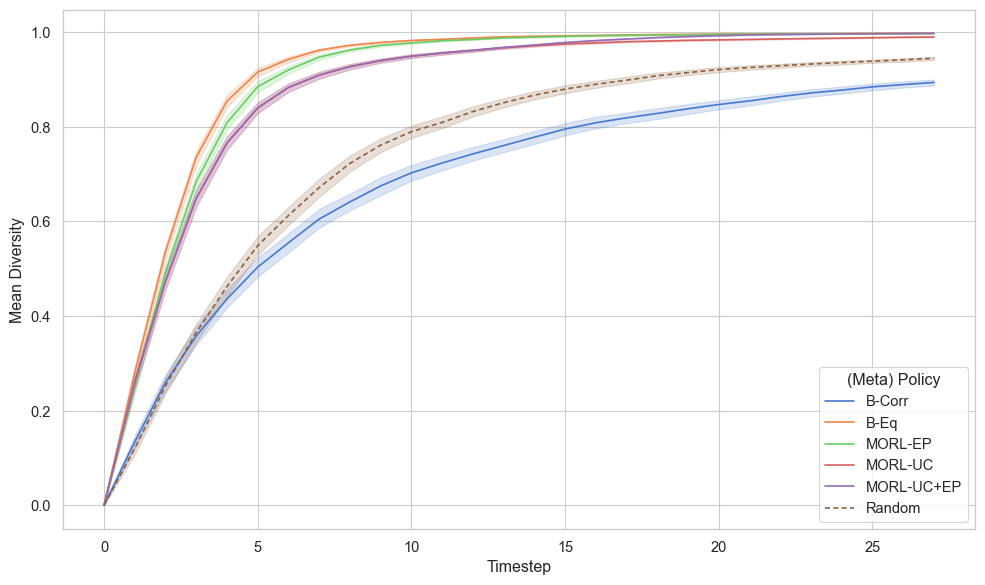

In [35]:
plotting_measures = ["Perceived Enjoyment", "Perceived Usefulness", "Return Willingness", "Diversity"]
policies_to_show = policies_to_show + ["Random"]
plot_df = reward_df[reward_df['policy'].isin(policies_to_show)]
policy_order = sorted(reward_df["policy"].unique())
for measure in plotting_measures:
    sim_utils.plot_seaborn(plot_df, measure, save_path=results_folder + f"figures\\outcomes\\{measure.lower().replace(' ', '_')}.svg")

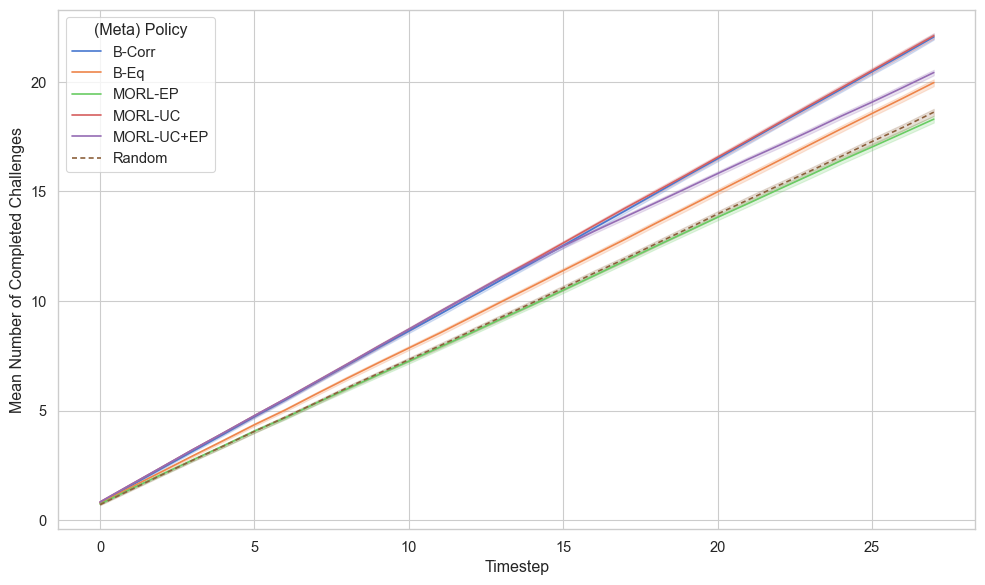

In [36]:
plot_df["Number of Completed Challenges"] = simulation_results["num_completed"]
sim_utils.plot_seaborn(plot_df, "Number of Completed Challenges", save_path=results_folder + "figures\\outcomes\\num_completed.svg")

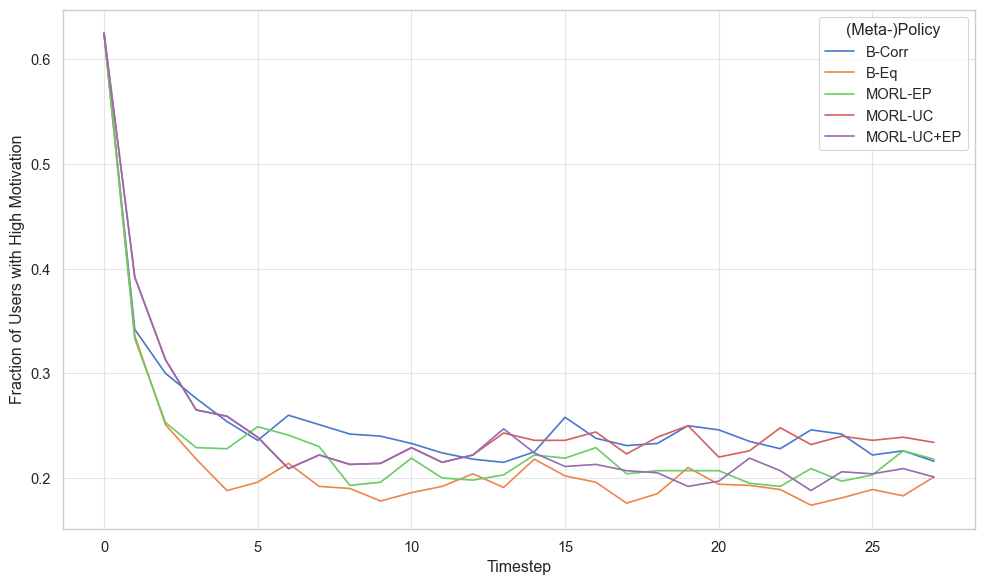

In [60]:
sim_utils.plot_state_trajectory(simulation_results[simulation_results['policy'].isin(policies_to_show)], threshold=2)

,policy,user,High Motivation
0,B-Corr,0,0.142857
1,B-Corr,1,0.000000
2,B-Corr,2,0.000000
3,B-Corr,3,0.142857
4,B-Corr,4,0.142857
...,...,...,...
5995,Random,995,0.000000
5996,Random,996,0.000000
5997,Random,997,0.000000
5998,Random,998,0.000000


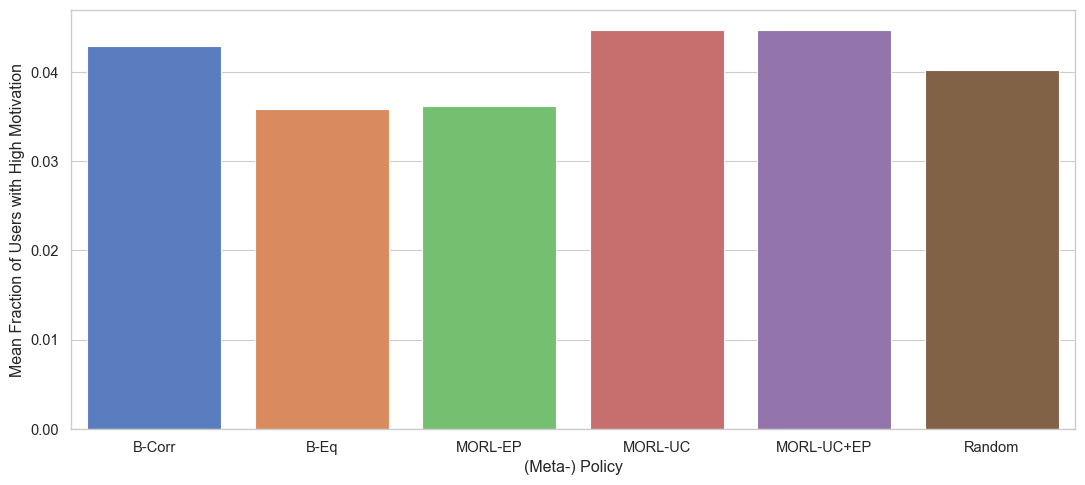

In [27]:
state_idx = 2
threshold = 2
state_diffs = simulation_results[simulation_results['policy'].isin(policies_to_show)].groupby(['policy', 'user'])['state'].apply(lambda states: (np.array(states)[state_idx] >= threshold).mean()).reset_index(name='High Motivation')
display(state_diffs)
plt.figure(figsize=(11, 5))
sns.barplot(
    data=state_diffs,
    x="policy",
    y="High Motivation",
    hue="policy",
    errorbar=None,
)
plt.ylabel("Mean Fraction of Users with High Motivation")
plt.xlabel("(Meta-) Policy")
# plt.savefig(results_folder + "figures\\high_motivation_fraction.svg", bbox_inches="tight")
plt.tight_layout()